# Exercise 2: Statistical Visualization

This exercise focuses on data visualization using `matplotlib` and `seaborn`. It covers the **M3-2: Statistical Visualization** learning outcomes. We will primarily use the Palmer Penguins dataset. Work through the sections in order.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("penguins")
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## A. Fundamentals of plotting

**1.** Explain the difference between a `figure` and an `axes` in `matplotlib`. (1-2 sentences)


The figure is the overall container for the visualization, while an axes is the individual plot area inside that figure where data are drawn and labeled.



**2.** Name the three figure-level functions in `seaborn`.



`sns.relplot`, `sns.displot`, `sns.catplot`



**3.** Briefly explain the difference between a **Histogram** and a **Barplot**. Which one is used to show the distribution of numerical data, and which is used for categorical data?



A histogram shows the distribution of numerical data by grouping values into bins. A barplot shows the size or count of categories, so it is used for categorical comparisons. Histogram = numerical distribution; Barplot = categorical data.



## B. Subplots and Grids

**1.** Using a seaborn **figure-level** function (like `sns.relplot` or `sns.displot`), create subplots using the `col` and `row` parameters. For example, plot `flipper_length_mm` vs `body_mass_g` across columns for `sex` and rows for `island`.

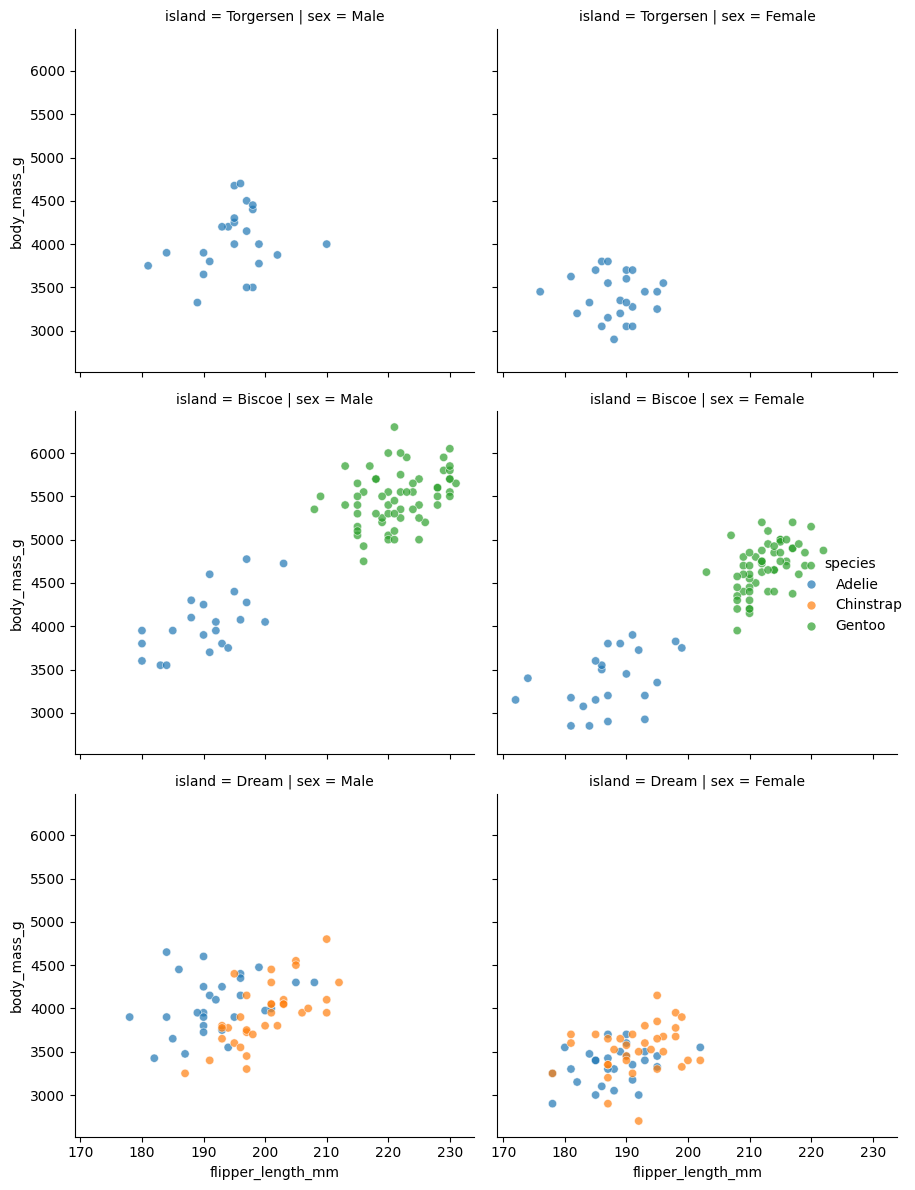

In [2]:
# Use a figure-level relational plot with faceting by sex and island
sns.relplot(
    data=df,
    x="flipper_length_mm",
    y="body_mass_g",
    col="sex",
    row="island",
    hue="species",
    kind="scatter",
    height=4,
    aspect=1,
    alpha=0.7,
)
plt.tight_layout()

**2.** Using **axes-level** functions, create a figure with subplots (e.g., 1 row and 2 columns) using `plt.subplots`. 
- Plot a scatterplot of `bill_length_mm` vs `bill_depth_mm` on the first axes (`ax1`).
- Plot a boxplot (or another axes-level plot of your choice) of `bill_length_mm` by `species` on the second axes (`ax2`).
- Make sure to use `sharey=True` (or `sharex=True`) where appropriate so the subplots are linked on the shared dimension.

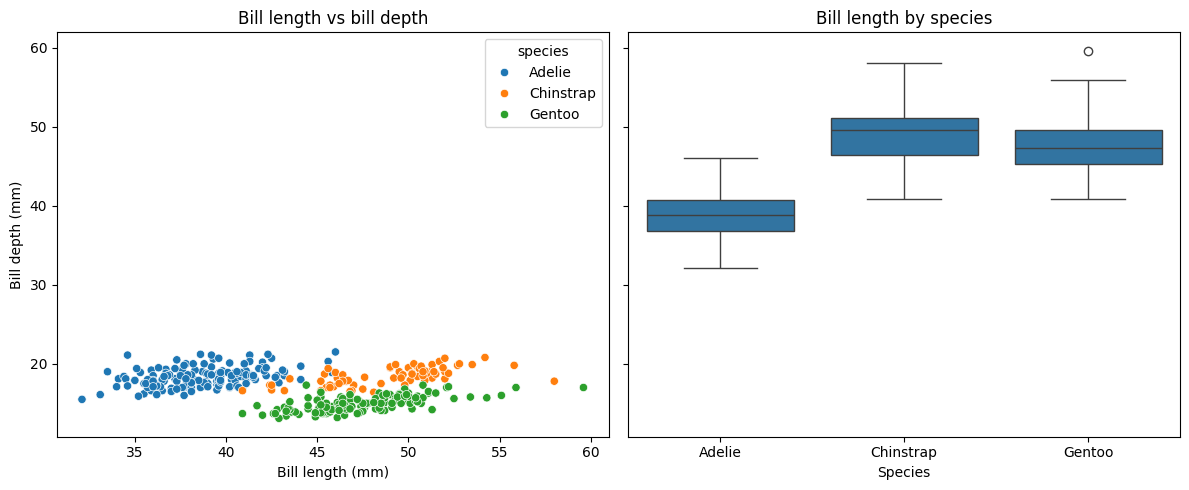

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    ax=ax1,
)
ax1.set_title("Bill length vs bill depth")
ax1.set_xlabel("Bill length (mm)")
ax1.set_ylabel("Bill depth (mm)")

sns.boxplot(
    data=df,
    x="species",
    y="bill_length_mm",
    ax=ax2,
)
ax2.set_title("Bill length by species")
ax2.set_xlabel("Species")
ax2.set_ylabel("Bill length (mm)")

plt.tight_layout()

## C. Visualizing Distributions

**1.** Write code to show a **box plot** of `flipper_length_mm` separated by `species`.

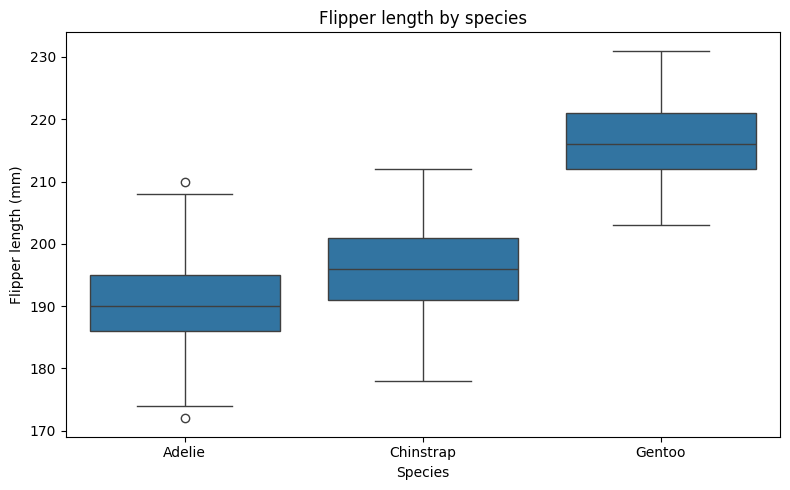

In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="species", y="flipper_length_mm")
plt.title("Flipper length by species")
plt.xlabel("Species")
plt.ylabel("Flipper length (mm)")
plt.tight_layout()



**2.** Show two distributions on the same figure axes: plot the distribution of `body_mass_g` grouped by `sex` (e.g., using `sns.kdeplot`, or `sns.histplot` with overlapping transparent bins).



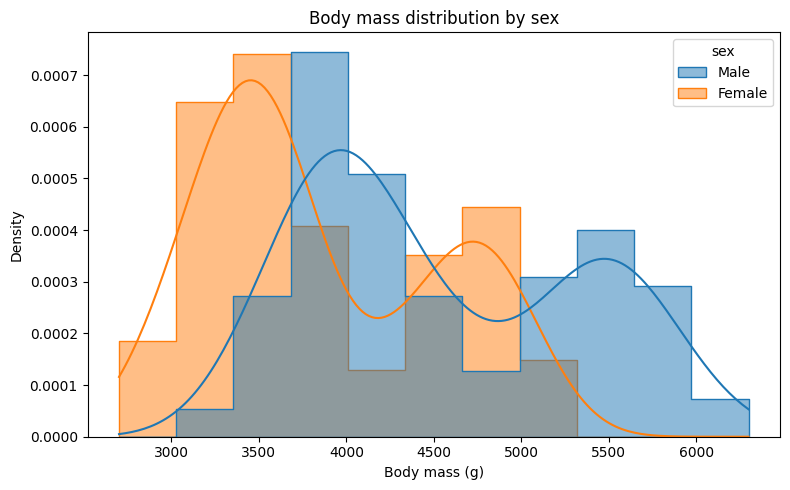

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(
    data=df,
    x="body_mass_g",
    hue="sex",
    kde=True,
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.5,
)
plt.title("Body mass distribution by sex")
plt.xlabel("Body mass (g)")
plt.ylabel("Density")
plt.tight_layout()



**3.** Plot the Empirical Cumulative Distribution Function (**ECDF**) for `body_mass_g`, split by `species`. Briefly interpret what the plot tells you about how the species compare in weight.



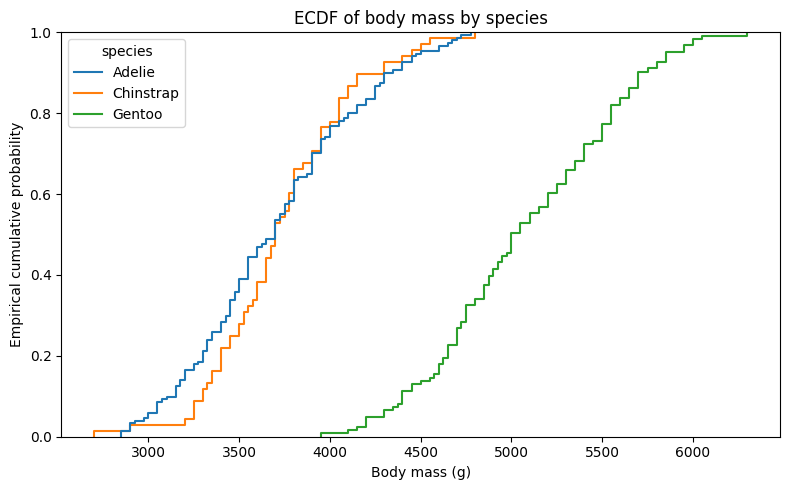

In [6]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(data=df, x="body_mass_g", hue="species")
plt.title("ECDF of body mass by species")
plt.xlabel("Body mass (g)")
plt.ylabel("Empirical cumulative probability")
plt.tight_layout()

The ECDF plot shows how the weight distributions differ by species: Adelie penguins tend to have lower body mass values, Gentoo penguins tend to have higher body mass values, and Chinstrap penguins fall in between. At a given mass value, the curve that rises fastest indicates the species with more individuals below that mass.


**4.** Plot a **bi-variate histogram** using `sns.histplot` showing `bill_length_mm` on the x-axis and `bill_depth_mm` on the y-axis. What does the intensity mapping (the color blocks) represent?



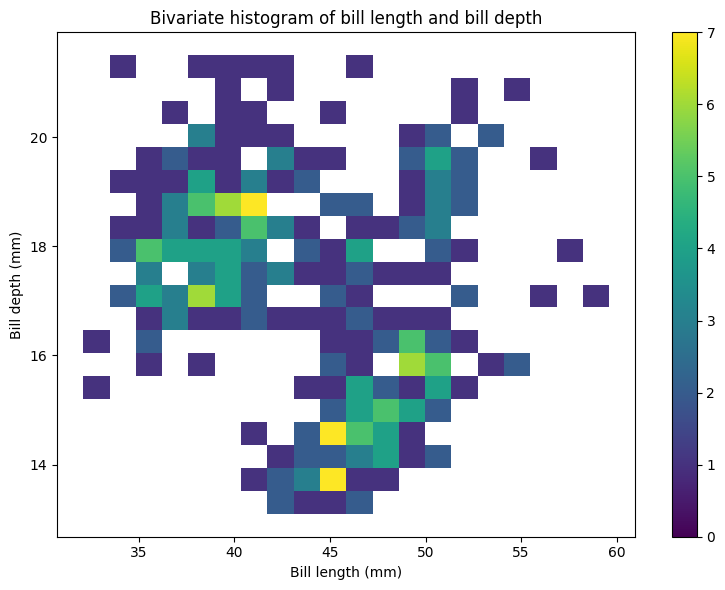

In [7]:
plt.figure(figsize=(8, 6))
sns.histplot(
    data=df,
    x="bill_length_mm",
    y="bill_depth_mm",
    bins=20,
    cbar=True,
    cmap="viridis",
    stat="count",
)
plt.title("Bivariate histogram of bill length and bill depth")
plt.xlabel("Bill length (mm)")
plt.ylabel("Bill depth (mm)")
plt.tight_layout()

The color intensity shows how many penguins fall into each rectangular bin of bill length and bill depth. Darker or brighter blocks mean more observations in that range, while lighter blocks mean fewer penguins.

## D. Categorical Data

**1.** Visualize numerical vs categorical relationships using `sns.catplot()`. Plot `bill_depth_mm` across different `island`s. Experiment with different categorical plot kinds (e.g., `kind='violin'` or `kind='swarm'`).

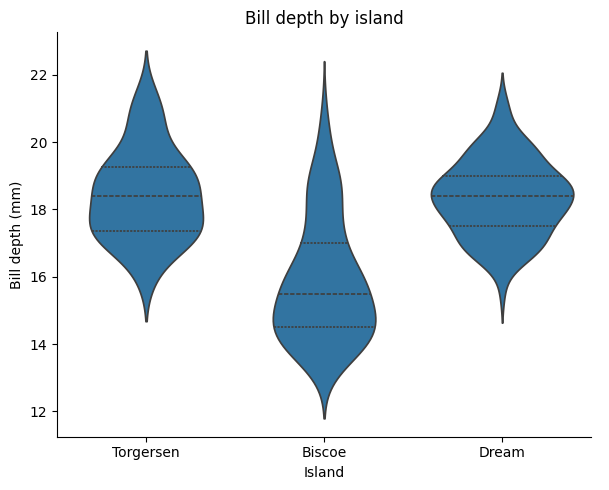

In [8]:
sns.catplot(
    data=df,
    x="island",
    y="bill_depth_mm",
    kind="violin",
    inner="quartile",
    height=5,
    aspect=1.2,
)
plt.title("Bill depth by island")
plt.ylabel("Bill depth (mm)")
plt.xlabel("Island")
plt.tight_layout()

**2.** Visualize multiple categorical variables in one plot. Show a count of penguins by `island`, and further separate the counts by `species` (using the `hue` parameter in a count plot or a similar approach).

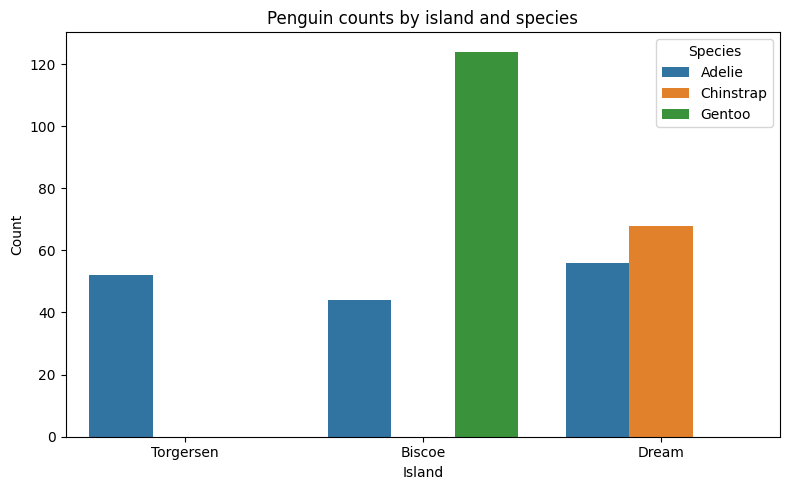

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="island", hue="species")
plt.title("Penguin counts by island and species")
plt.xlabel("Island")
plt.ylabel("Count")
plt.legend(title="Species")
plt.tight_layout()

## E. Relational Plots and Aesthetics

**1.** Relate two numerical variables using a simple **scatter plot**: plot `bill_length_mm` vs `flipper_length_mm`.

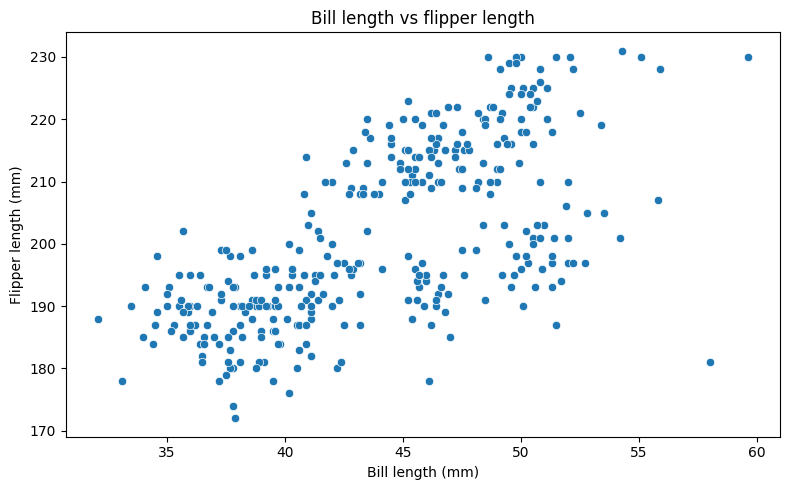

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="bill_length_mm", y="flipper_length_mm")
plt.title("Bill length vs flipper length")
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")
plt.tight_layout()

**2.** Enhance the scatter plot from the previous step by using different **colors** (`hue`), **markers** (`style`), and **sizes** (`size`) based on other variables in the dataset. Make the plot visually distinct and ensure it is readable.

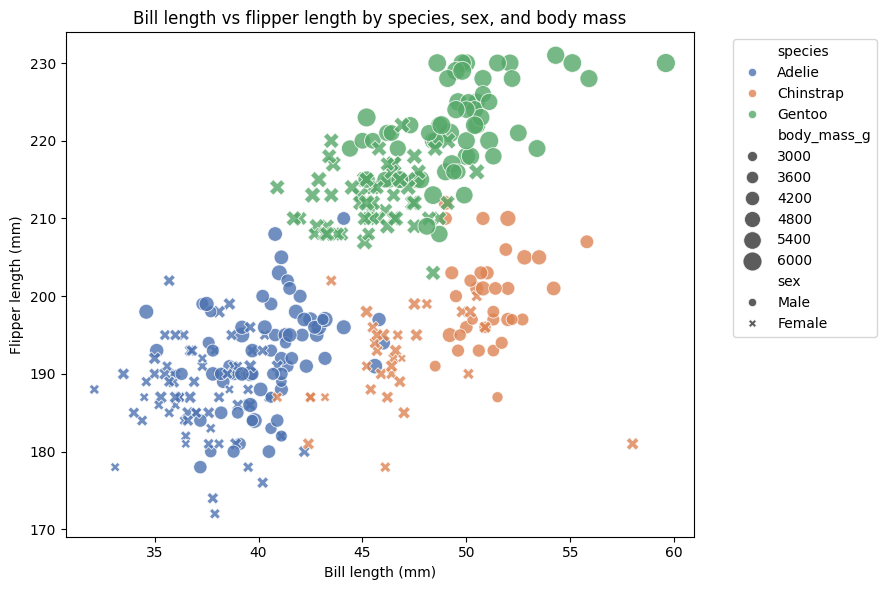

In [11]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    style="sex",
    size="body_mass_g",
    palette="deep",
    sizes=(40, 200),
    alpha=0.8,
)
plt.title("Bill length vs flipper length by species, sex, and body mass")
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()